In [5]:
!sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess, time
subprocess.Popen(["ollama", "serve"])
time.sleep(5)
print("서버 실행 완료")

!ollama pull qwen2.5:7b

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
서버 실행 완료



In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import json
import random
import requests
from collections import defaultdict
from sklearn.metrics import cohen_kappa_score
from google.colab import userdata

SAVE_DIR = "/content/drive/MyDrive"
SAMPLE_N = 2

with open(f"{SAVE_DIR}/plan_review_seed_v1.json", encoding="utf-8") as f:
    data = json.load(f)

# 섹션별 충족/미흡 2개씩 샘플링
random.seed(42)
by_section = defaultdict(list)
for item in data:
    if item["label"] in ["충족", "미흡"]:
        by_section[item["section"]].append(item)

samples = []
for sec, items in by_section.items():
    samples.extend(random.sample(items, min(SAMPLE_N, len(items))))

print(f"샘플 수: {len(samples)}개")

SYSTEM_PROMPT = """당신은 공공 SW 사업수행계획서를 검토하는 감리 전문가입니다.
계획서 내용을 읽고 아래 형식으로만 답하세요.

판정: (충족/미흡/불가 중 하나)
코멘트: (판단 근거 2~3문장)"""

def evaluate_with_qwen(item):
    try:
        response = requests.post(
            "http://localhost:11434/api/generate",
            json={
                "model": "qwen2.5:7b",
                "prompt": f"{SYSTEM_PROMPT}\n\n{item['input']}",
                "stream": False,
            },
            timeout=120,
        )
        return response.json()["response"].strip()
    except Exception as e:
        print(f"오류: {e}")
        return None

import time
for i, item in enumerate(samples):
    item["qwen_output"] = evaluate_with_qwen(item)
    print(f"{i+1}/{len(samples)} 완료 | {item['section']} | gold:{item['label']}")
    time.sleep(1)

print("Qwen 판정 완료")

샘플 수: 32개
1/32 완료 | 1. 사업명 | gold:미흡
2/32 완료 | 1. 사업명 | gold:충족
3/32 완료 | 2. 사업기간 | gold:충족
4/32 완료 | 2. 사업기간 | gold:충족
5/32 완료 | 3. 사업목적 | gold:미흡
6/32 완료 | 3. 사업목적 | gold:충족
7/32 완료 | 4. 사업범위 | gold:미흡
8/32 완료 | 4. 사업범위 | gold:미흡
9/32 완료 | 5. 사업추진체계 | gold:미흡
10/32 완료 | 5. 사업추진체계 | gold:미흡
11/32 완료 | 6. 사업추진절차 | gold:충족
12/32 완료 | 6. 사업추진절차 | gold:미흡
13/32 완료 | 7. 산출물계획 | gold:미흡
14/32 완료 | 7. 산출물계획 | gold:충족
15/32 완료 | 8. 일정계획 | gold:충족
16/32 완료 | 8. 일정계획 | gold:미흡
17/32 완료 | 9. 공정별 투입인력계획 | gold:충족
18/32 완료 | 9. 공정별 투입인력계획 | gold:미흡
19/32 완료 | 10. 보고계획 | gold:미흡
20/32 완료 | 10. 보고계획 | gold:충족
21/32 완료 | 11. 표준화계획 | gold:충족
22/32 완료 | 11. 표준화계획 | gold:충족
23/32 완료 | 12. 품질보증계획 | gold:충족
24/32 완료 | 12. 품질보증계획 | gold:충족
25/32 완료 | 13. 위험관리계획 | gold:충족
26/32 완료 | 13. 위험관리계획 | gold:미흡
27/32 완료 | 14. 보안대책 | gold:미흡
28/32 완료 | 14. 보안대책 | gold:미흡
29/32 완료 | 15. 교육계획 | gold:충족
30/32 완료 | 15. 교육계획 | gold:충족
31/32 완료 | 16. 발주기관 협조요청사항 | gold:충족
32/32 완료 | 16. 발주기관 협조요청사항 | gold:충족
Qwen 판정 완료


In [9]:
def extract_verdict(output):
    if not output:
        return None
    for line in output.split("\n"):
        if line.startswith("판정:"):
            return line.replace("판정:", "").strip()
    return None

gpt_verdicts, qwen_verdicts, valid_samples = [], [], []

for item in samples:
    gpt_v  = item["label"]
    qwen_v = extract_verdict(item["qwen_output"])
    if gpt_v and qwen_v:
        gpt_verdicts.append(gpt_v)
        qwen_verdicts.append(qwen_v)
        valid_samples.append(item)

matches = sum(g == q for g, q in zip(gpt_verdicts, qwen_verdicts))
print(f"유효 샘플: {len(valid_samples)}개")
print(f"일치: {matches}/{len(valid_samples)} ({matches/len(valid_samples)*100:.1f}%)")

kappa = cohen_kappa_score(gpt_verdicts, qwen_verdicts)
print(f"\nCohen's Kappa: {kappa:.4f}")

if kappa >= 0.8:
    print("우수")
elif kappa >= 0.6:
    print("양호")
elif kappa >= 0.4:
    print("보통 (일부 재검토 필요)")
else:
    print("미흡 (데이터 재검토 필요)")

# 불일치 케이스
mismatches = [
    {
        "section": item["section"],
        "criteria": item["criteria"],
        "gold": gpt_v,
        "qwen": qwen_v,
        "input": item["input"][:200],
        "qwen_output": item["qwen_output"],
    }
    for item, gpt_v, qwen_v in zip(valid_samples, gpt_verdicts, qwen_verdicts)
    if gpt_v != qwen_v
]

print(f"\n불일치 케이스: {len(mismatches)}개")
for i, m in enumerate(mismatches):
    print(f"\n[{i+1}] [{m['section']}] {m['criteria']}")
    print(f"  gold: {m['gold']} / qwen: {m['qwen']}")

# 저장
output = {"kappa": kappa, "mismatches": mismatches}
with open(f"{SAVE_DIR}/plan_iaa_result_v1.json", "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)
print("\n저장 완료")

유효 샘플: 32개
일치: 27/32 (84.4%)

Cohen's Kappa: 0.6748
양호

불일치 케이스: 5개

[1] [4. 사업범위] 추적성
  gold: 미흡 / qwen: 충족

[2] [6. 사업추진절차] 완전성
  gold: 미흡 / qwen: 충족

[3] [7. 산출물계획] 수정용이성
  gold: 미흡 / qwen: 충족

[4] [9. 공정별 투입인력계획] 정확성
  gold: 충족 / qwen: 미흡

[5] [10. 보고계획] 수정용이성
  gold: 미흡 / qwen: 충족

저장 완료


# 시각화

In [10]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('한글 폰트 설정 완료')

한글 폰트 설정 완료


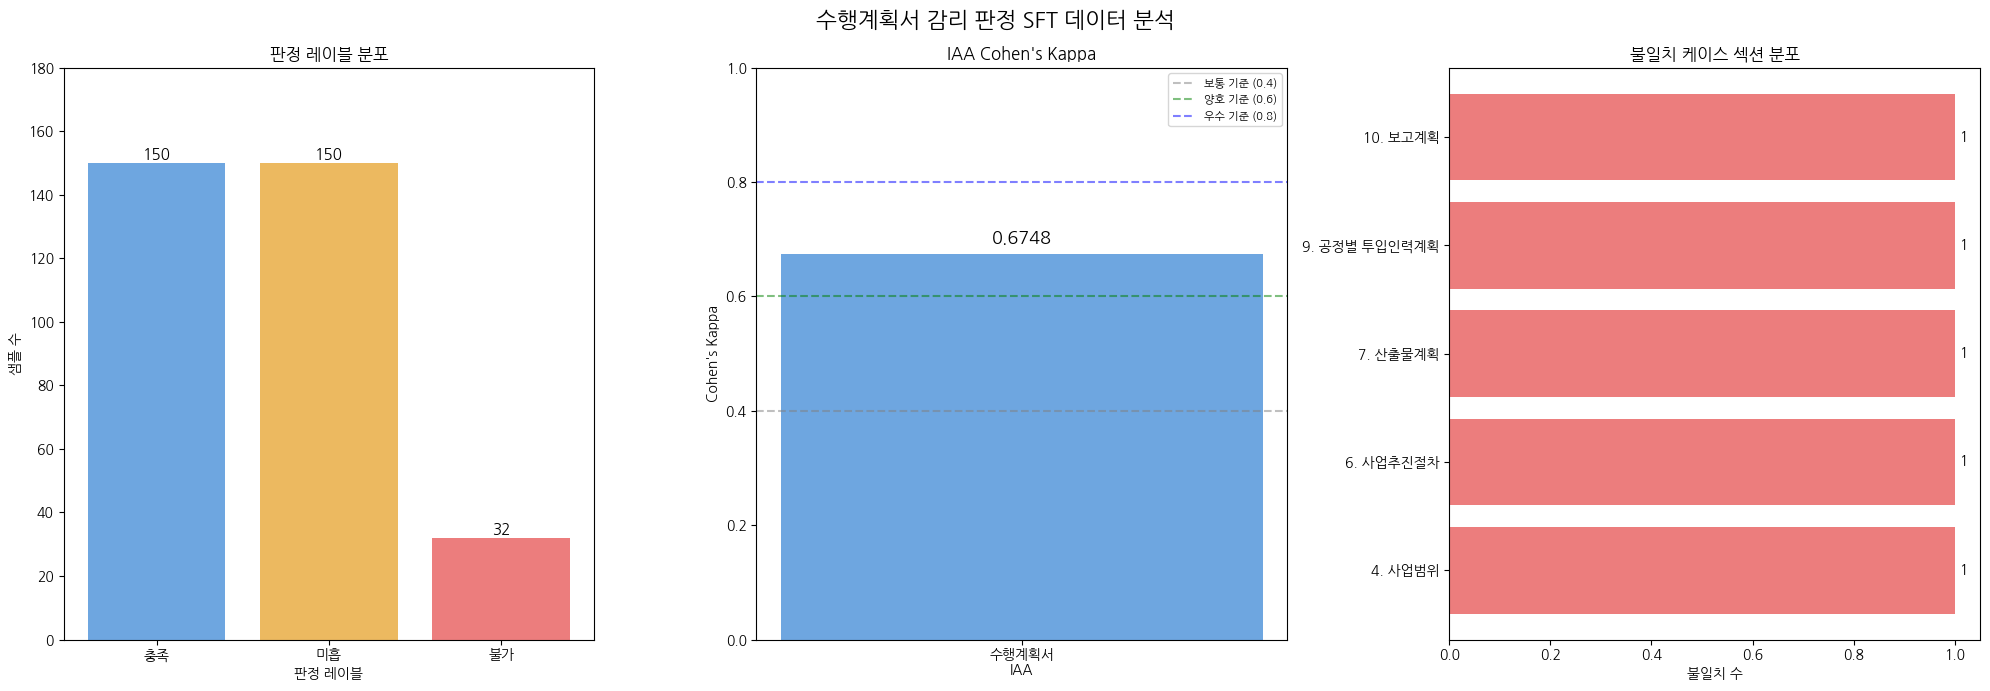

저장 완료 | Kappa: 0.6748 | 불일치: 5개


In [11]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

SAVE_DIR = "/content/drive/MyDrive"

with open(f"{SAVE_DIR}/plan_review_seed_v1.json", encoding="utf-8") as f:
    seed = json.load(f)

with open(f"{SAVE_DIR}/plan_iaa_result_v1.json", encoding="utf-8") as f:
    iaa = json.load(f)

kappa = iaa["kappa"]
mismatches = iaa["mismatches"]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('수행계획서 감리 판정 SFT 데이터 분석', fontsize=16, fontweight='bold')

# 1. 레이블 분포
ax1 = axes[0]
label_cnt = Counter(d["label"] for d in seed)
labels = ["충족", "미흡", "불가"]
values = [label_cnt.get(l, 0) for l in labels]
colors = ['#4A90D9', '#E8A838', '#E85D5D']
bars = ax1.bar(labels, values, color=colors, alpha=0.8)
ax1.set_title('판정 레이블 분포', fontweight='bold')
ax1.set_xlabel('판정 레이블')
ax1.set_ylabel('샘플 수')
ax1.set_ylim(0, max(values) * 1.2)
for bar, val in zip(bars, values):
    ax1.annotate(f'{val}',
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=11)

# 2. Cohen's Kappa
ax2 = axes[1]
ax2.bar(['수행계획서\nIAA'], [kappa], color='#4A90D9', alpha=0.8, width=0.4)
ax2.axhline(y=0.4, color='gray', linestyle='--', alpha=0.5, label='보통 기준 (0.4)')
ax2.axhline(y=0.6, color='green', linestyle='--', alpha=0.5, label='양호 기준 (0.6)')
ax2.axhline(y=0.8, color='blue', linestyle='--', alpha=0.5, label='우수 기준 (0.8)')
ax2.set_title("IAA Cohen's Kappa", fontweight='bold')
ax2.set_ylabel("Cohen's Kappa")
ax2.set_ylim(0, 1.0)
ax2.legend(fontsize=8)
ax2.annotate(f'{kappa:.4f}',
             xy=(0, kappa), xytext=(0, 8), textcoords='offset points',
             ha='center', fontsize=13, fontweight='bold')

# 3. 불일치 섹션 분포
ax3 = axes[2]
mismatch_sections = Counter(m["section"] for m in mismatches)
if mismatch_sections:
    sec_labels = list(mismatch_sections.keys())
    sec_values = list(mismatch_sections.values())
    bars = ax3.barh(sec_labels, sec_values, color='#E85D5D', alpha=0.8)
    ax3.set_title('불일치 케이스 섹션 분포', fontweight='bold')
    ax3.set_xlabel('불일치 수')
    for bar, val in zip(bars, sec_values):
        ax3.annotate(f'{val}',
                     xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                     xytext=(3, 0), textcoords='offset points', va='center', fontsize=10)
else:
    ax3.text(0.5, 0.5, '불일치 없음', ha='center', va='center', fontsize=14)
    ax3.set_title('불일치 케이스 섹션 분포', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/plan_iaa_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"저장 완료 | Kappa: {kappa:.4f} | 불일치: {len(mismatches)}개")

In [ ]:
import json
from collections import Counter

with open("/workspace/workit_sft_merged_v1.json", encoding="utf-8") as f:
    data = json.load(f)

cnt = Counter()
for d in data:
    verdict = d["messages"][2]["content"].split("\n")[0].replace("판정:", "").strip()
    cnt[verdict] += 1

total = len(data)
for k, v in cnt.most_common():
    print(f"{k}: {v}개 ({v/total*100:.1f}%)")